In [1]:
import sys
sys.path.insert(0, '..')
import json
import re
import collections
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from collections import Counter
from wordcloud import WordCloud, STOPWORDS
HAS_WORDCLOUD = True
import emoji as emoji_lib
HAS_EMOJI = True

plt.rcParams.update({
    'figure.dpi':        150,
    'figure.facecolor':  'white',
    'axes.facecolor':    '#FAFAFA',
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

CLS_COLORS = {
    'hatespeech': '#111111',
    'offensive':  '#888888',
    'normal':     '#CCCCCC',
}
CLS_NAMES   = ['hatespeech', 'offensive', 'normal']
CLS_DISPLAY = {'hatespeech': 'Hate Speech', 'offensive': 'Offensive', 'normal': 'Normal'}

PLOTS_DIR = Path('plots/hatexplain')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
URL = "https://raw.githubusercontent.com/hate-alert/HateXplain/master/Data/dataset.json"

with urllib.request.urlopen(URL) as response:
    raw = json.loads(response.read().decode())

rows = []

for post_id, ex in raw.items():
    tokens = ex["post_tokens"]
    text = " ".join(tokens)
    annotators = ex["annotators"]
    rationales = ex.get("rationales", [])
    votes = [a["label"] for a in annotators]
    vote_counts = Counter(votes)

    majority_label = vote_counts.most_common(1)[0][0]
    unique_votes = len(set(votes))
    all_agree = (unique_votes == 1)
    n_unique_votes = unique_votes
    all_targets = [target for annotator in annotators for target in annotator.get("target", [])]
    primary_target = (Counter(all_targets).most_common(1)[0][0] if all_targets else "None")
    if rationales:
        flat_rationales = [ value for rationale in rationales for value in rationale]
        rat_density = (sum(flat_rationales) / len(flat_rationales) if flat_rationales else 0.0)

    else:
        rat_density = 0.0

    rows.append({
        "post_id": post_id,
        "text": text,
        "tokens": tokens,
        "label": majority_label,
        "votes": votes,
        "vote_counts": dict(vote_counts),
        "all_agree": all_agree,
        "n_unique_votes": n_unique_votes,
        "n_annotators": len(annotators),
        "primary_target": primary_target,
        "rationale_density": rat_density,
        "rationales": rationales,
        "word_count": len(tokens),
        "char_count": len(text),
        "unique_words": len(set(t.lower() for t in tokens)),
    })
df = pd.DataFrame(rows)
print(f"\nLoaded {len(df):,} posts")

print("\nColumns:")
print(df.columns.tolist())


Loaded 20,148 posts

Columns:
['post_id', 'text', 'tokens', 'label', 'votes', 'vote_counts', 'all_agree', 'n_unique_votes', 'n_annotators', 'primary_target', 'rationale_density', 'rationales', 'word_count', 'char_count', 'unique_words']


In [3]:
print(f"\nLabel distribution:")
print(df['label'].value_counts())


Label distribution:
label
normal        8153
hatespeech    6234
offensive     5761
Name: count, dtype: int64


In [4]:
print("=" * 55)
print("HATEXPLAIN — DATASET OVERVIEW")
print("=" * 55)
print(f"Total posts:      {len(df):,}")
print(f"Unique post IDs:  {df['post_id'].nunique():,}")
print(f"Columns:          {len(df.columns)}")
print(f"Missing values:")
print(df[['text','label','word_count']].isnull().sum().to_string())
print(f"\nDuplicates (text): {df['text'].duplicated().sum()}")
print(f"Min word count:    {df['word_count'].min()}")
print(f"Max word count:    {df['word_count'].max()}")
print(f"Mean word count:   {df['word_count'].mean():.1f}")
print(f"Median word count: {df['word_count'].median():.1f}")
print(f"95th percentile:   {df['word_count'].quantile(0.95):.0f} words")
print("=" * 55)

HATEXPLAIN — DATASET OVERVIEW
Total posts:      20,148
Unique post IDs:  20,148
Columns:          15
Missing values:
text          0
label         0
word_count    0

Duplicates (text): 39
Min word count:    2
Max word count:    165
Mean word count:   23.6
Median word count: 21.0
95th percentile:   49 words


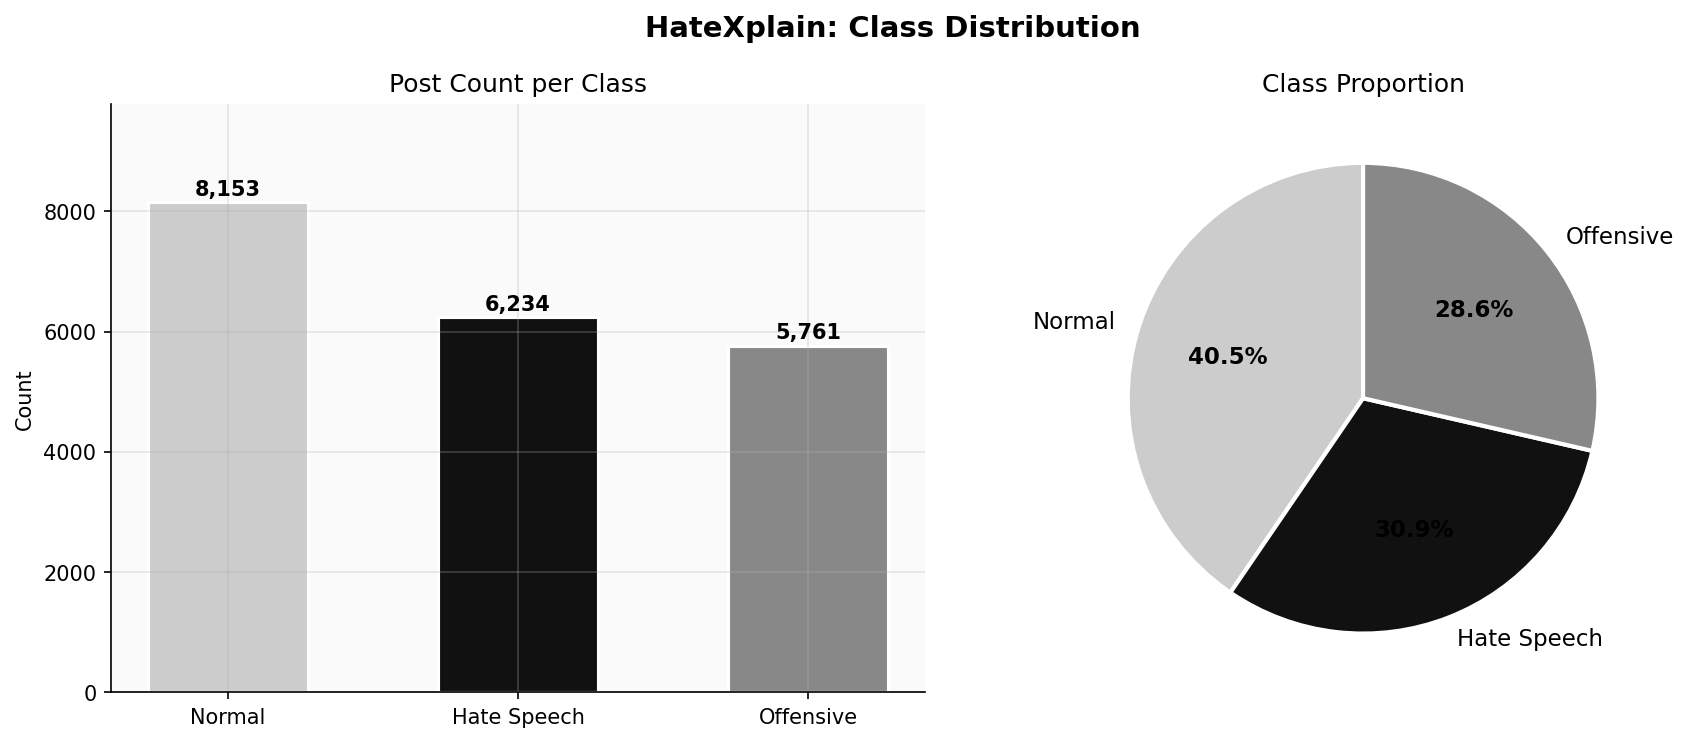


Class counts:
label
normal        8153
hatespeech    6234
offensive     5761


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('HateXplain: Class Distribution', fontsize=14, fontweight='bold')

counts = df['label'].value_counts()
colors = [CLS_COLORS[c] for c in counts.index]

ax = axes[0]
bars = ax.bar([CLS_DISPLAY[c] for c in counts.index], counts.values,
              color=colors, edgecolor='white', linewidth=1.5, width=0.55)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Post Count per Class')
ax.set_ylabel('Count')
ax.set_ylim(0, max(counts.values) * 1.2)

ax = axes[1]
wedges, texts, autotexts = ax.pie(
    counts.values,
    labels=[CLS_DISPLAY[c] for c in counts.index],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold')
ax.set_title('Class Proportion')

plt.tight_layout()
plt.savefig(PLOTS_DIR / '01_class_distribution.png', bbox_inches='tight')
plt.show()
print(f"\nClass counts:\n{counts.to_string()}")

C:\Users\hario\AppData\Local\Temp\ipykernel_23920\1359434691.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_cls,
C:\Users\hario\AppData\Local\Temp\ipykernel_23920\1359434691.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax.boxplot(char_per_cls,


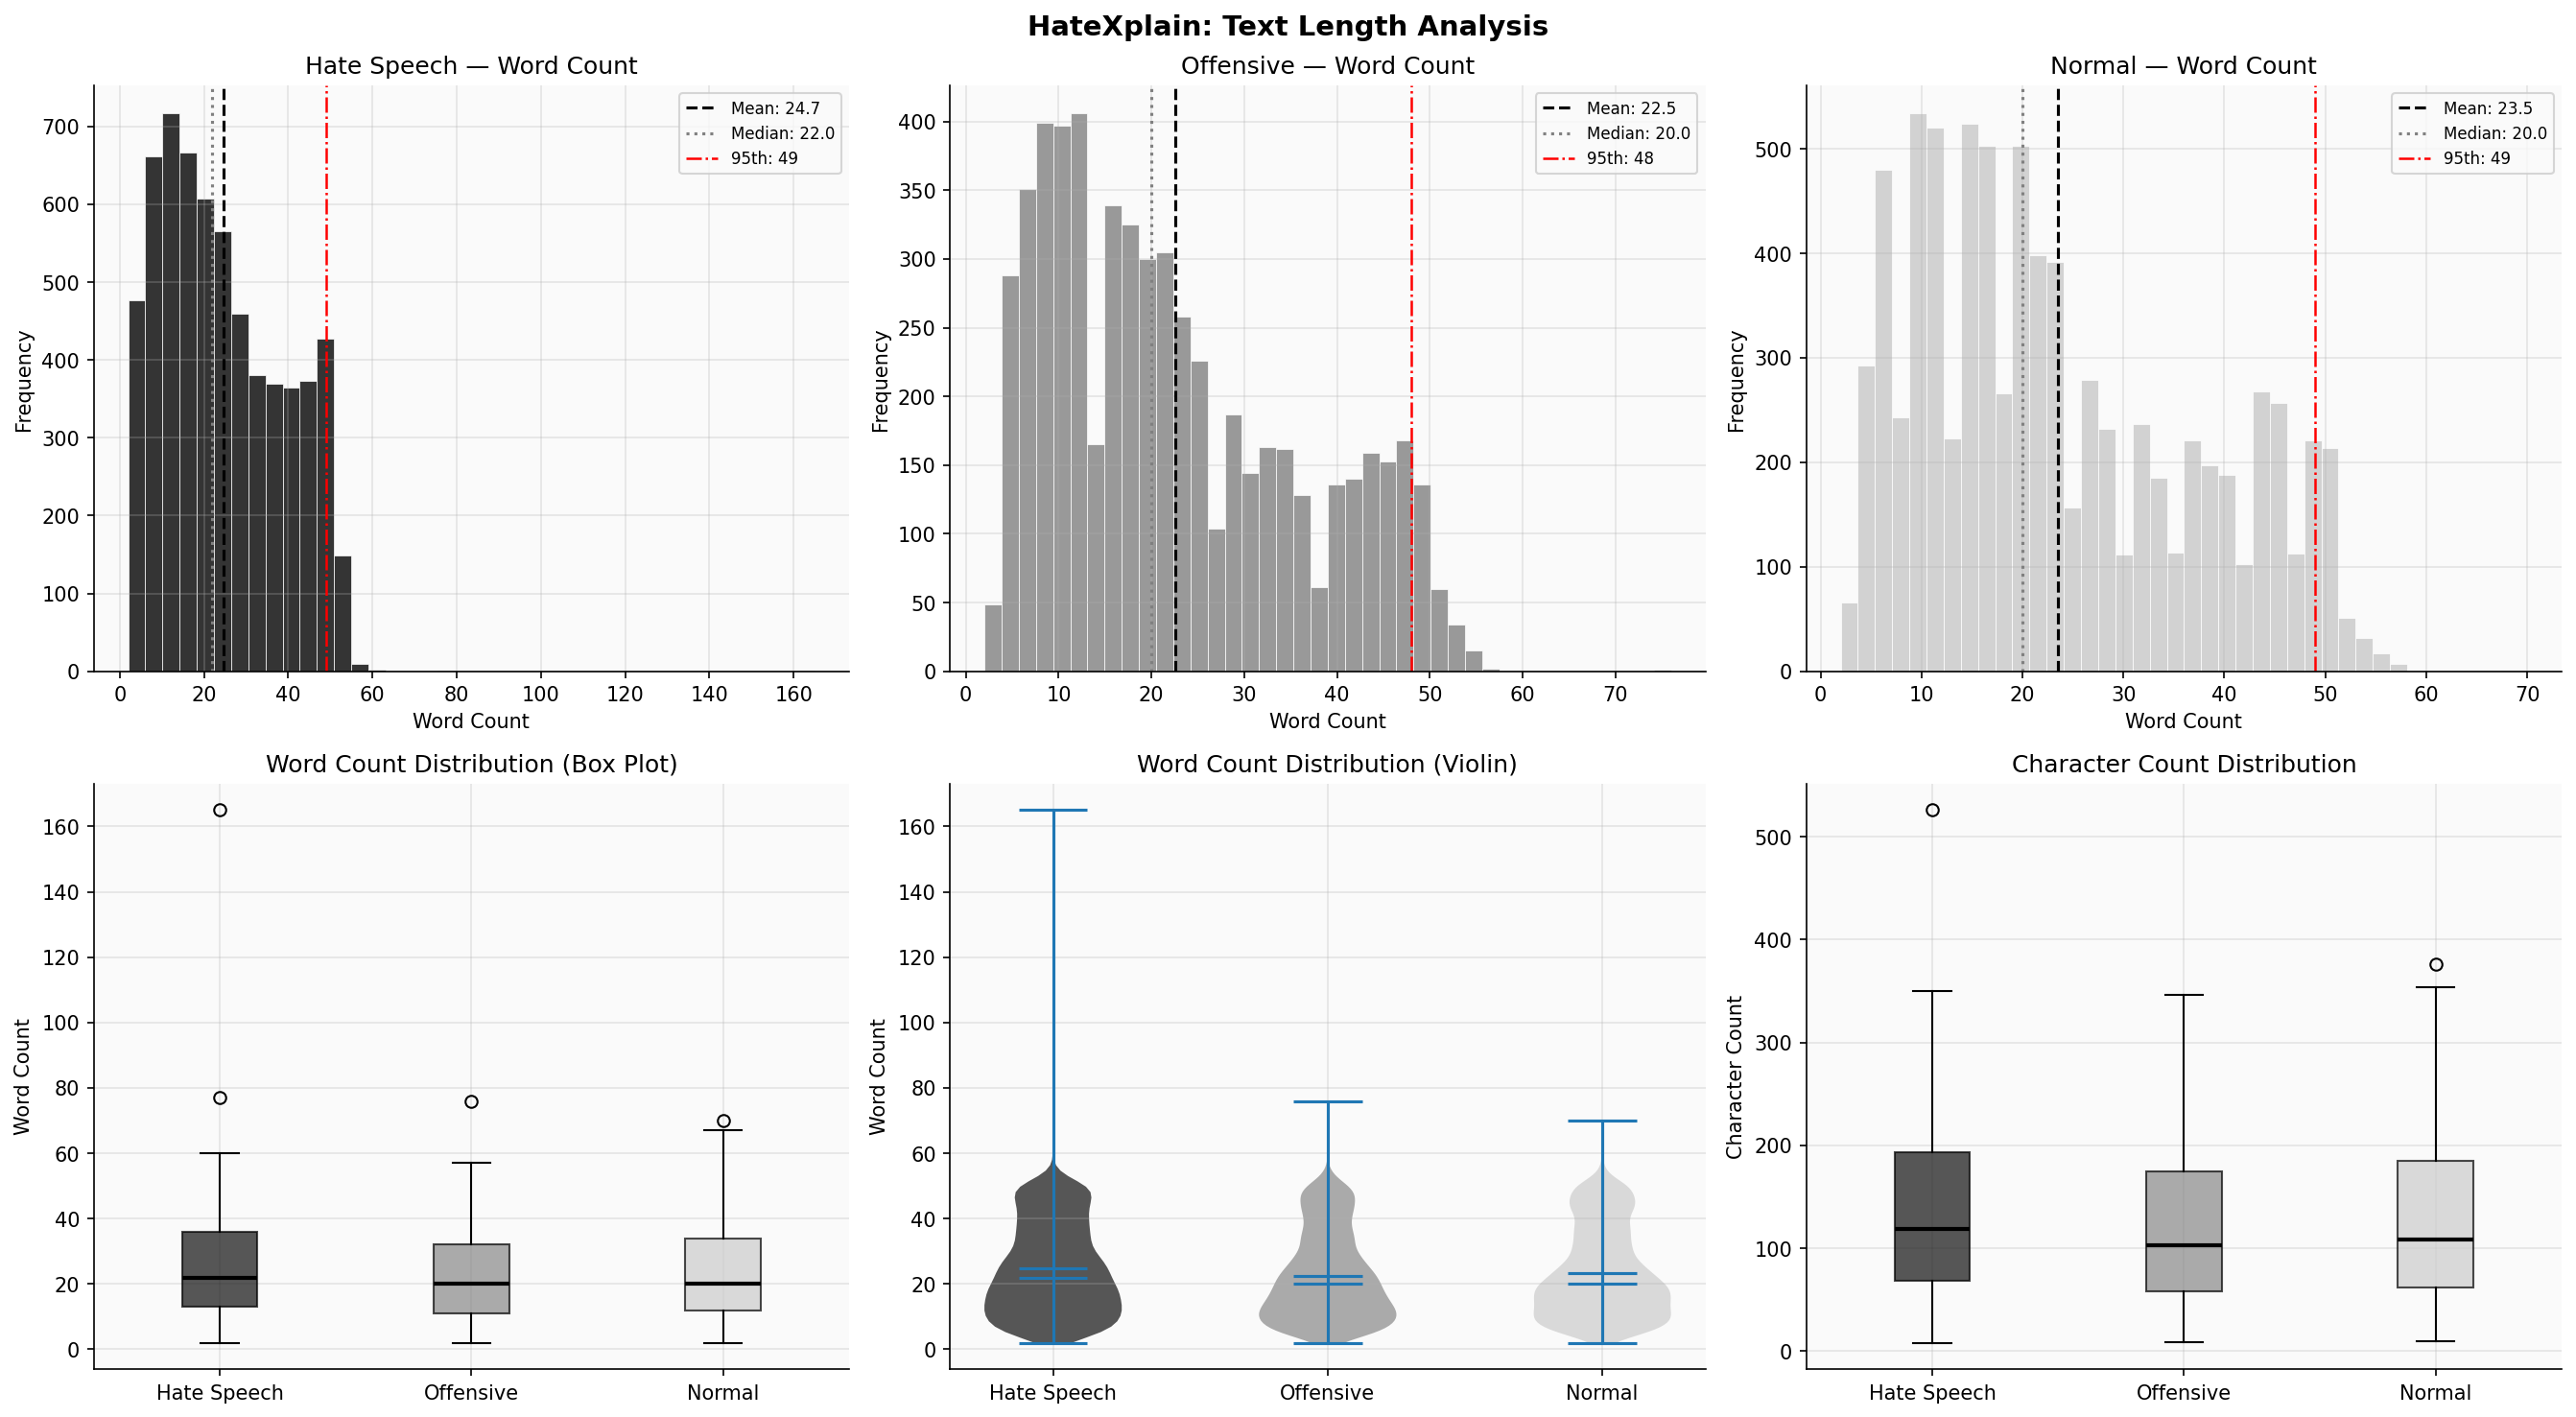


Text Length Statistics per Class:
           word_count                                             char_count  \
                count   mean    std  min   25%   50%   75%    max      count   
label                                                                          
hatespeech     6234.0  24.65  14.08  2.0  13.0  22.0  36.0  165.0     6234.0   
normal         8153.0  23.48  13.74  2.0  12.0  20.0  34.0   70.0     8153.0   
offensive      5761.0  22.53  13.57  2.0  11.0  20.0  32.0   76.0     5761.0   

                                                            
              mean    std   min   25%    50%    75%    max  
label                                                       
hatespeech  133.19  78.43   8.0  68.0  119.0  193.0  526.0  
normal      126.96  78.54  10.0  62.0  108.0  185.0  376.0  
offensive   121.24  76.82   9.0  58.0  103.0  175.0  346.0  


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('HateXplain: Text Length Analysis', fontsize=14, fontweight='bold')

for col, cls in enumerate(CLS_NAMES):
    ax = axes[0][col]
    data = df[df['label'] == cls]['word_count']
    ax.hist(data, bins=40, color=CLS_COLORS[cls],
            edgecolor='white', linewidth=0.4, alpha=0.85)
    ax.axvline(data.mean(), color='black', linestyle='--',
               linewidth=1.5, label=f'Mean: {data.mean():.1f}')
    ax.axvline(data.median(), color='gray', linestyle=':',
               linewidth=1.5, label=f'Median: {data.median():.1f}')
    ax.axvline(data.quantile(0.95), color='red', linestyle='-.',
               linewidth=1.2, label=f'95th: {data.quantile(0.95):.0f}')
    ax.set_title(f'{CLS_DISPLAY[cls]} — Word Count')
    ax.set_xlabel('Word Count')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

# VIOLIN PLOT
ax = axes[1][0]
data_per_cls = [df[df['label']==c]['word_count'].values for c in CLS_NAMES]
bp = ax.boxplot(data_per_cls,
                labels=[CLS_DISPLAY[c] for c in CLS_NAMES],
                patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for patch, cls in zip(bp['boxes'], CLS_NAMES):
    patch.set_facecolor(CLS_COLORS[cls])
    patch.set_alpha(0.7)
ax.set_title('Word Count Distribution (Box Plot)')
ax.set_ylabel('Word Count')

# Violin plot for word count
ax = axes[1][1]
parts = ax.violinplot(data_per_cls,
                      positions=range(len(CLS_NAMES)),
                      showmeans=True, showmedians=True)
for pc, cls in zip(parts['bodies'], CLS_NAMES):
    pc.set_facecolor(CLS_COLORS[cls])
    pc.set_alpha(0.7)
ax.set_xticks(range(len(CLS_NAMES)))
ax.set_xticklabels([CLS_DISPLAY[c] for c in CLS_NAMES])
ax.set_title('Word Count Distribution (Violin)')
ax.set_ylabel('Word Count')

# Char count boxplot
ax = axes[1][2]
char_per_cls = [df[df['label']==c]['char_count'].values for c in CLS_NAMES]
bp2 = ax.boxplot(char_per_cls,
                 labels=[CLS_DISPLAY[c] for c in CLS_NAMES],
                 patch_artist=True,
                 medianprops=dict(color='black', linewidth=2))
for patch, cls in zip(bp2['boxes'], CLS_NAMES):
    patch.set_facecolor(CLS_COLORS[cls])
    patch.set_alpha(0.7)
ax.set_title('Character Count Distribution')
ax.set_ylabel('Character Count')

plt.tight_layout()
plt.savefig(PLOTS_DIR / '02_text_length.png', bbox_inches='tight')
plt.show()

# Stats table
stats = df.groupby('label')[['word_count', 'char_count']].describe().round(2)
print("\nText Length Statistics per Class:")
print(stats)

Vocabulary Richness Analysis

Hate Speech:
  Total tokens                   82910
  Unique tokens                  14551
  TTR (Type-Token Ratio)         0.1755
  Avg unique/post                21.7
  Vocab richness                 High

Offensive:
  Total tokens                   67971
  Unique tokens                  13274
  TTR (Type-Token Ratio)         0.1953
  Avg unique/post                20.0
  Vocab richness                 High

Normal:
  Total tokens                   98765
  Unique tokens                  17298
  TTR (Type-Token Ratio)         0.1751
  Avg unique/post                20.5
  Vocab richness                 High


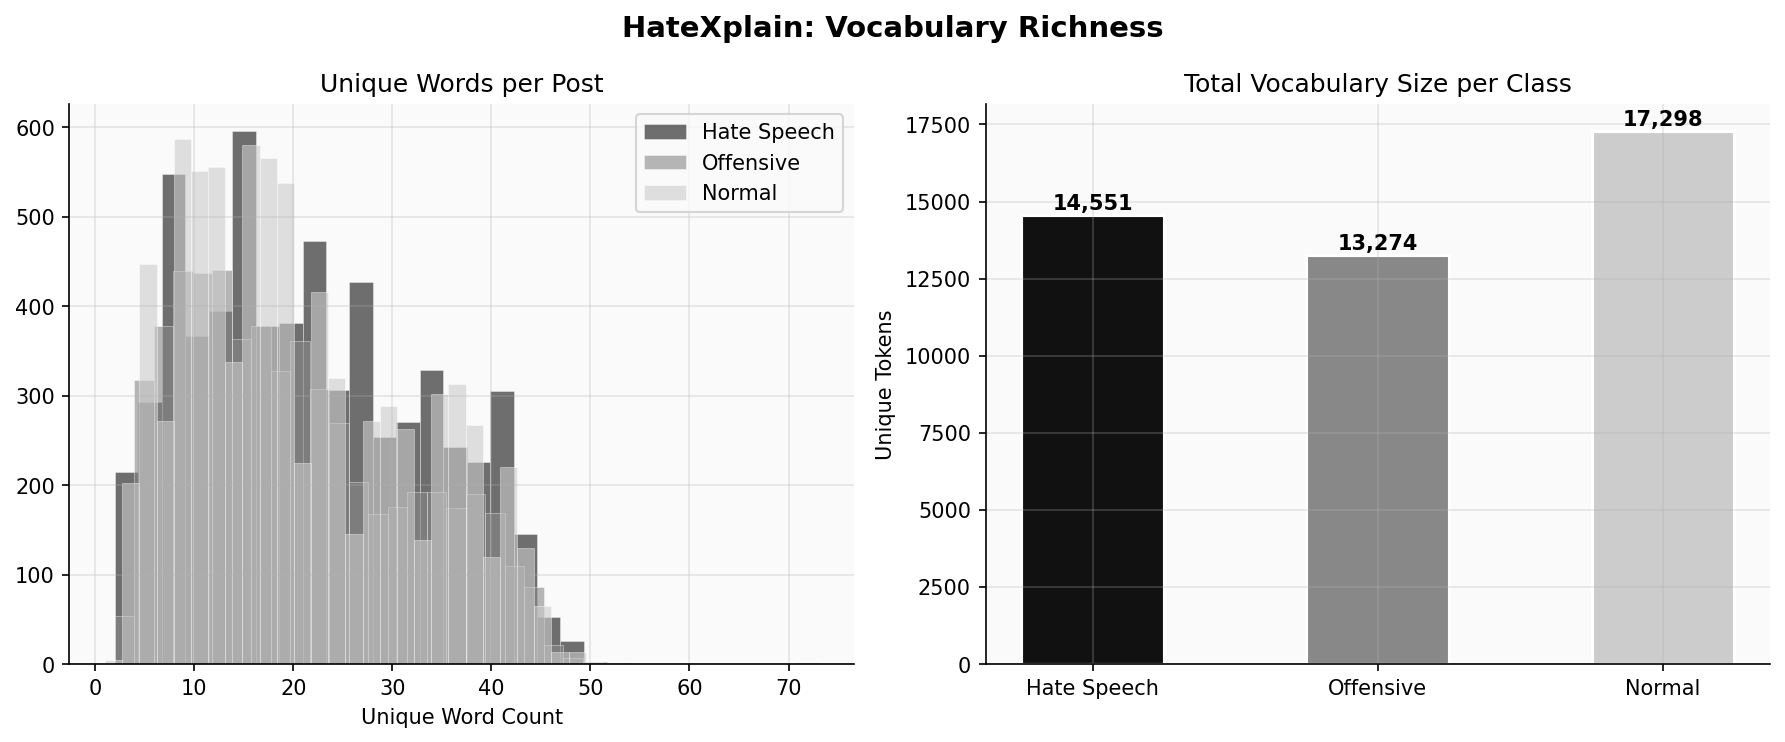

In [7]:
print("Vocabulary Richness Analysis")
print("=" * 55)

STOPWORDS_SET = set(STOPWORDS)
vocab_stats = {}
for cls in CLS_NAMES:
    subset = df[df['label'] == cls]
    all_tokens = [
        t.lower() for row in subset['tokens']
        for t in row
        if t.lower() not in STOPWORDS_SET
        and t.isalpha()
        and len(t) > 1
    ]
    total   = len(all_tokens)
    unique  = len(set(all_tokens))
    ttr     = unique / total if total > 0 else 0
    vocab_stats[cls] = {
        'Total tokens':   total,
        'Unique tokens':  unique,
        'TTR (Type-Token Ratio)': round(ttr, 4),
        'Avg unique/post': round(subset['unique_words'].mean(), 1),
        'Vocab richness':  'High' if ttr > 0.1 else 'Medium' if ttr > 0.06 else 'Low',
    }
    print(f"\n{CLS_DISPLAY[cls]}:")
    for k, v in vocab_stats[cls].items():
        print(f"  {k:<30} {v}")


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('HateXplain: Vocabulary Richness', fontsize=14, fontweight='bold')

ax = axes[0]
for cls in CLS_NAMES:
    ax.hist(df[df['label']==cls]['unique_words'],
            bins=30, color=CLS_COLORS[cls],
            alpha=0.6, label=CLS_DISPLAY[cls],
            edgecolor='white', linewidth=0.3)
ax.set_title('Unique Words per Post')
ax.set_xlabel('Unique Word Count')
ax.legend()


ax = axes[1]
sizes = [vocab_stats[c]['Unique tokens'] for c in CLS_NAMES]
bars  = ax.bar([CLS_DISPLAY[c] for c in CLS_NAMES], sizes,
               color=[CLS_COLORS[c] for c in CLS_NAMES],
               edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', va='bottom', fontweight='bold')
ax.set_title('Total Vocabulary Size per Class')
ax.set_ylabel('Unique Tokens')

plt.tight_layout()
plt.savefig(PLOTS_DIR / '03_vocabulary_richness.png', bbox_inches='tight')
plt.show()

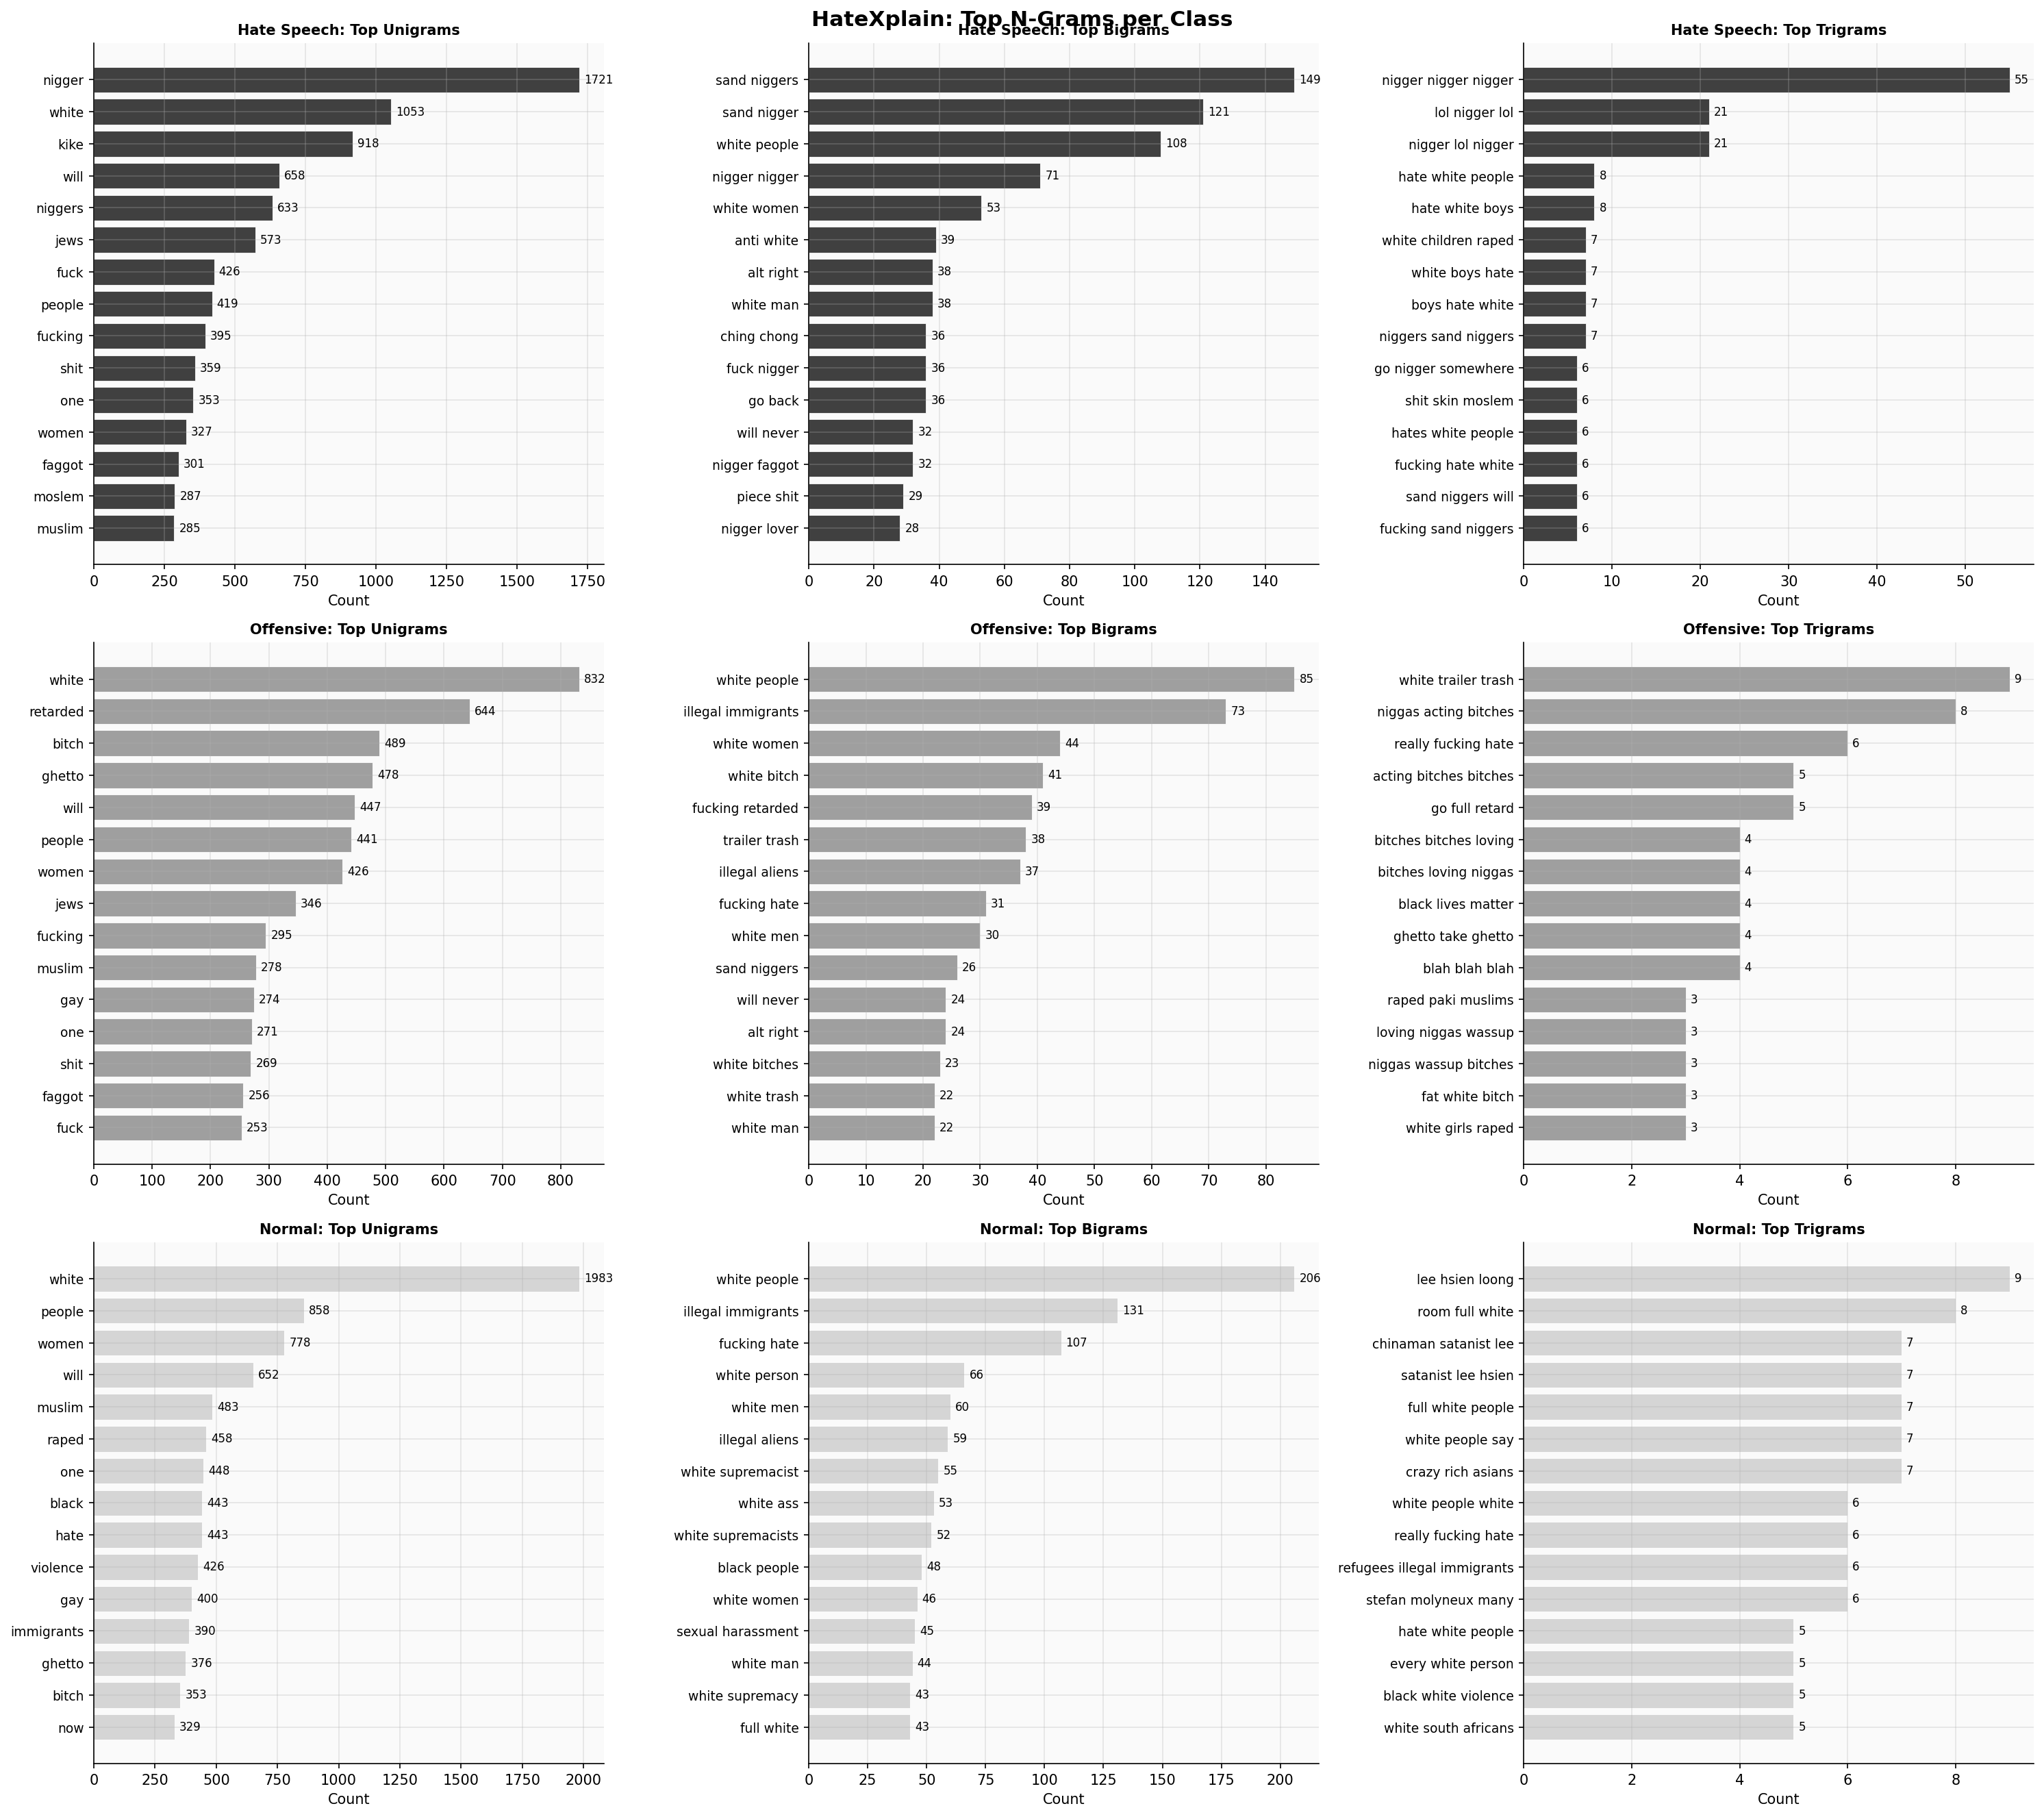

In [8]:
from collections import Counter

def get_ngrams(token_lists, n, stopwords=STOPWORDS_SET, top_k=20):
    ngrams = []
    for tokens in token_lists:
        clean = [t.lower() for t in tokens
                 if t.lower() not in stopwords
                 and t.isalpha() and len(t) > 1]
        for i in range(len(clean) - n + 1):
            ngrams.append(' '.join(clean[i:i+n]))
    return Counter(ngrams).most_common(top_k)

fig, axes = plt.subplots(3, 3, figsize=(20, 18))
fig.suptitle('HateXplain: Top N-Grams per Class', fontsize=15, fontweight='bold')

for row, cls in enumerate(CLS_NAMES):
    tokens_list = df[df['label']==cls]['tokens'].tolist()
    color = CLS_COLORS[cls]
    
    for col, (n, title) in enumerate([(1,'Unigrams'), (2,'Bigrams'), (3,'Trigrams')]):
        ax = axes[row][col]
        ngrams = get_ngrams(tokens_list, n, top_k=15)
        
        if not ngrams:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center')
            continue
        
        words, counts = zip(*ngrams)
        y_pos = range(len(words))
        
        bars = ax.barh(list(y_pos), list(counts),
                       color=color, alpha=0.8,
                       edgecolor='white', linewidth=0.5)
        ax.set_yticks(list(y_pos))
        ax.set_yticklabels(list(words), fontsize=9)
        ax.invert_yaxis()
        ax.set_title(f'{CLS_DISPLAY[cls]}: Top {title}',
                     fontweight='bold', fontsize=10)
        ax.set_xlabel('Count')
        
        for bar, count in zip(bars, counts):
            ax.text(bar.get_width() + max(counts)*0.01, bar.get_y() + bar.get_height()/2,
                    str(count), va='center', fontsize=8)

plt.tight_layout()
plt.savefig(PLOTS_DIR / '04_ngrams.png', bbox_inches='tight')
plt.show()

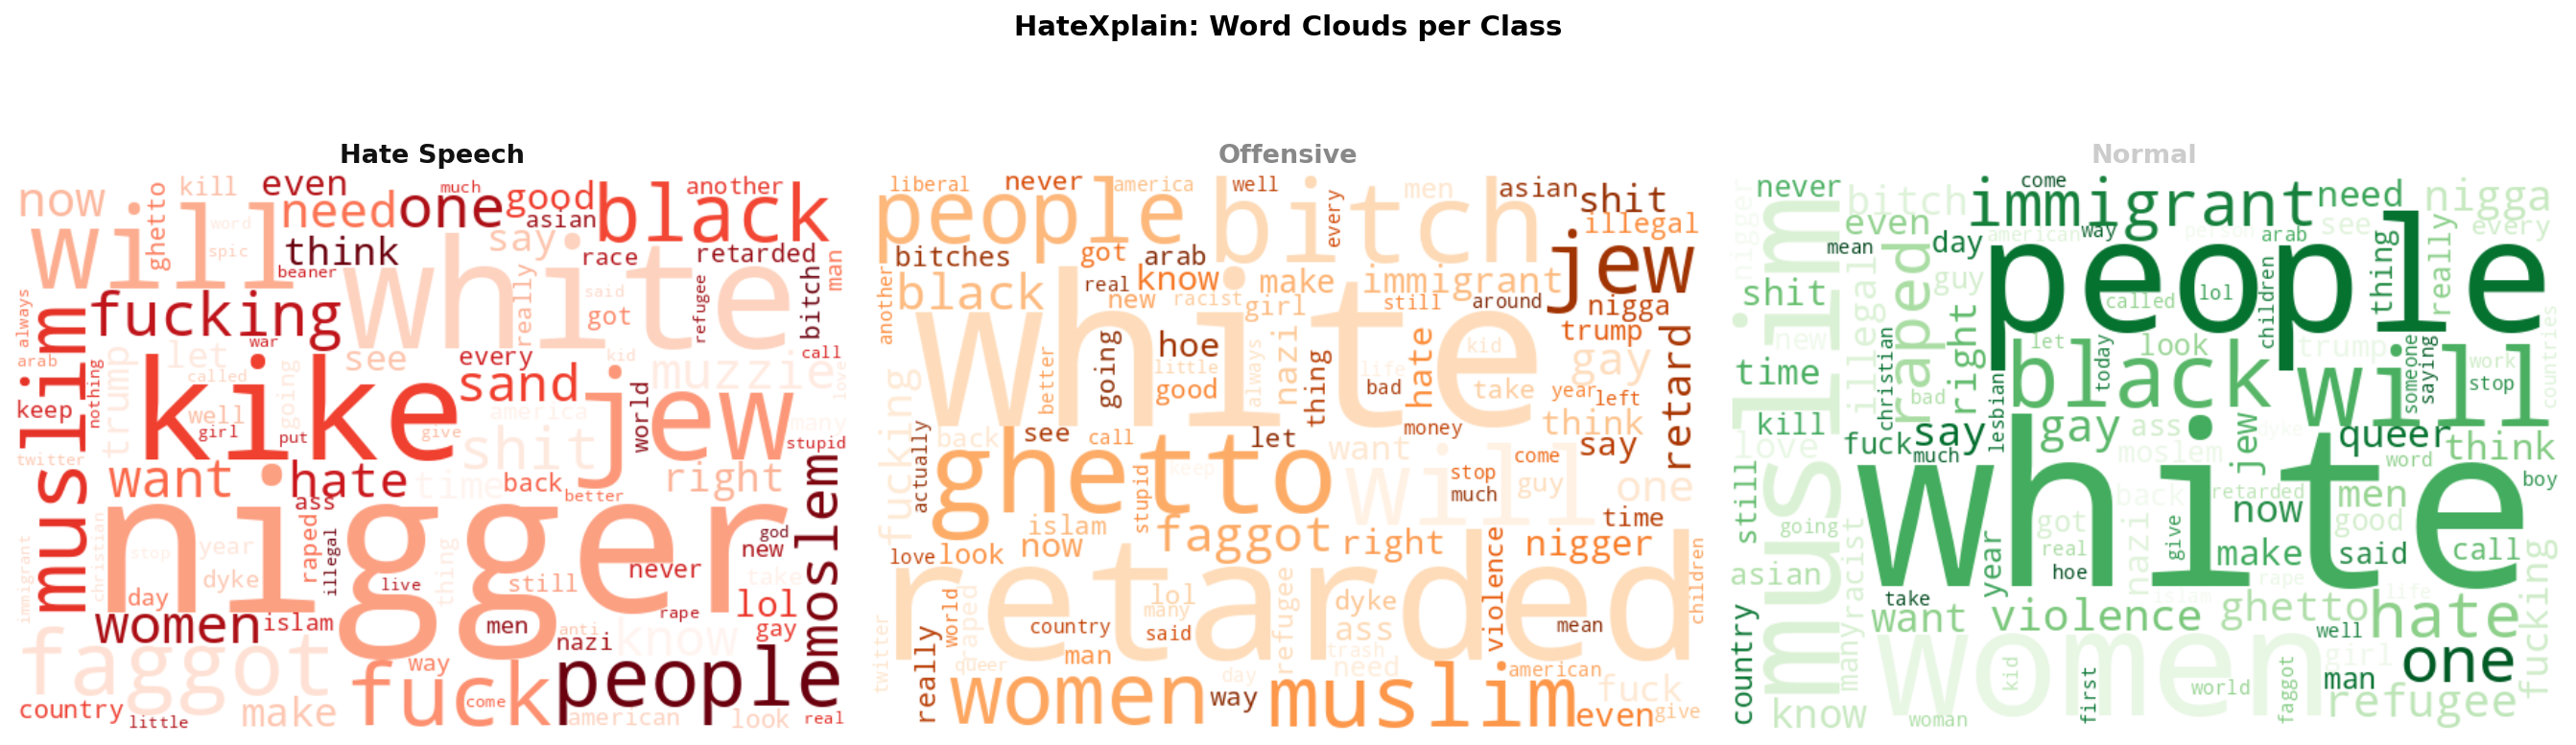

In [9]:
if HAS_WORDCLOUD:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('HateXplain: Word Clouds per Class', 
                 fontsize=14, fontweight='bold')

    for ax, cls in zip(axes, CLS_NAMES):
        tokens_list = df[df['label']==cls]['tokens'].tolist()
        text = ' '.join([
            t.lower() for tokens in tokens_list
            for t in tokens
            if t.lower() not in STOPWORDS_SET
            and t.isalpha() and len(t) > 2
        ])
        
        wc = WordCloud(
            width=600, height=400,
            background_color='white',
            colormap='Reds' if cls == 'hatespeech' else
                     'Oranges' if cls == 'offensive' else 'Greens',
            max_words=100,
            stopwords=STOPWORDS_SET,
            collocations=False,
        ).generate(text)
        
        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(f'{CLS_DISPLAY[cls]}', fontsize=13, fontweight='bold',
                     color=CLS_COLORS[cls])

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / '05_wordclouds.png', bbox_inches='tight')
    plt.show()

INTER-ANNOTATOR AGREEMENT
Fleiss' Kappa: 0.4597
Interpretation: Moderate agreement

Full agreement (3/3): 9,845 (48.9%)
Disagreement (2/3):   10,303 (51.1%)


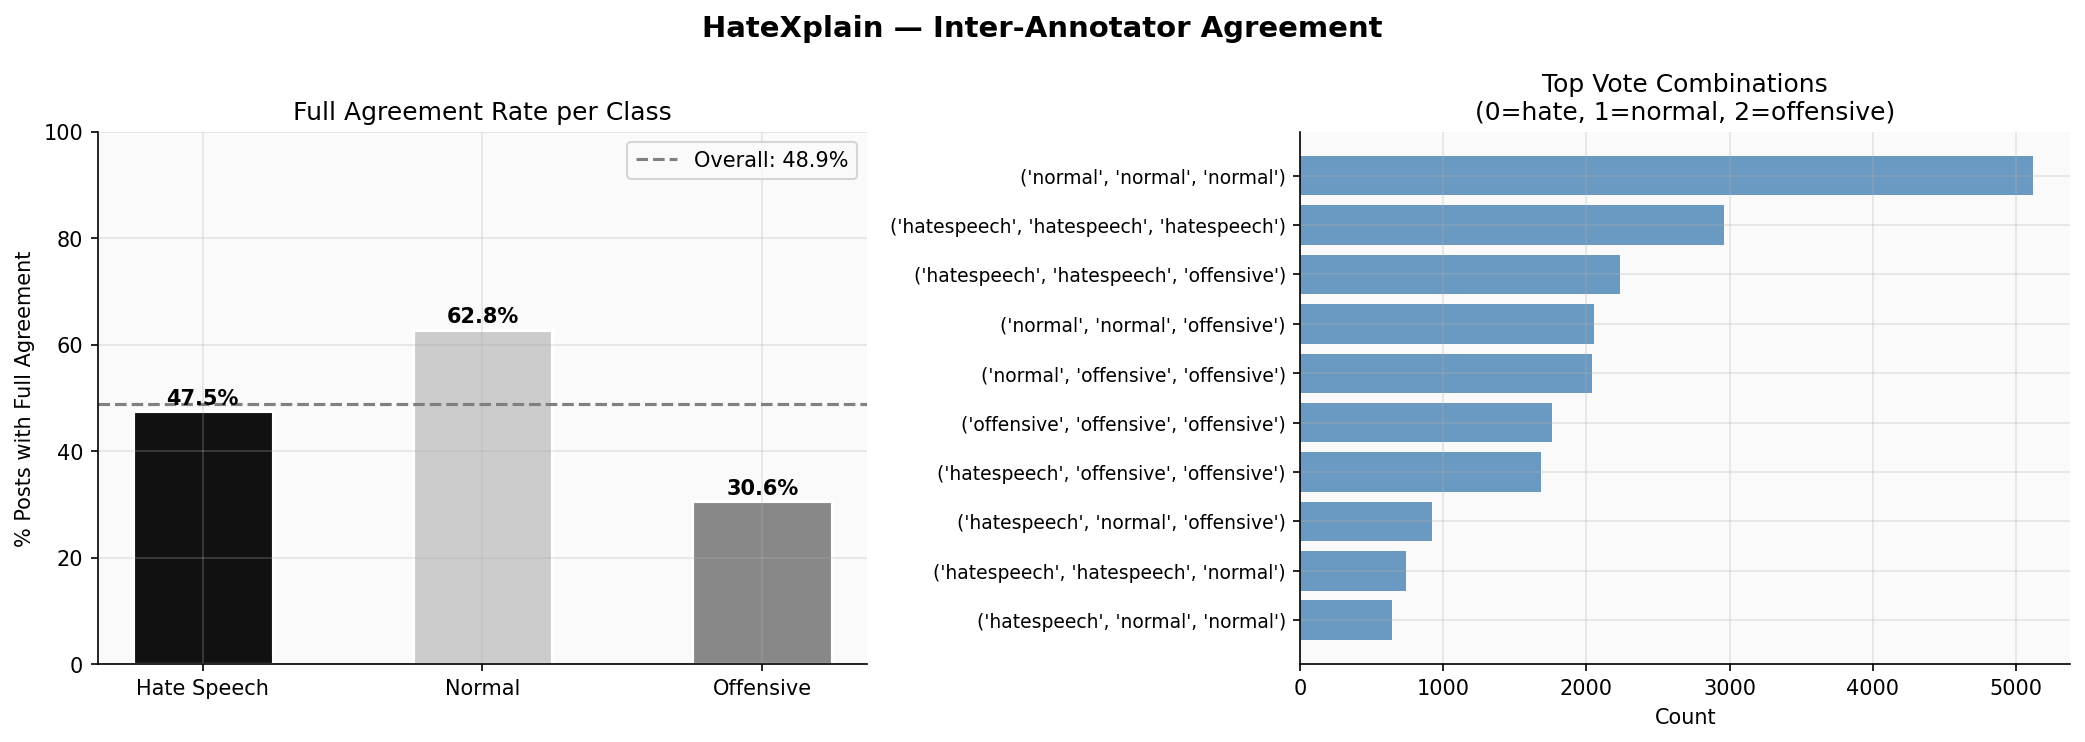

In [10]:
def fleiss_kappa(ratings_matrix):
    """
    Compute Fleiss' Kappa.
    ratings_matrix: (n_subjects, n_categories) — count of raters per category
    """
    n_subjects, n_categories = ratings_matrix.shape
    n_raters = ratings_matrix.sum(axis=1)[0]
    
    p_j = ratings_matrix.sum(axis=0) / (n_subjects * n_raters)
    P_e  = (p_j ** 2).sum()
    
    P_i = ((ratings_matrix ** 2).sum(axis=1) - n_raters) / (n_raters * (n_raters - 1))
    P_bar = P_i.mean()
    
    if P_e == 1.0:
        return 1.0
    return (P_bar - P_e) / (1 - P_e)

# Build ratings matrix: each row = post, cols = [hate, normal, offensive]
label_to_idx = {'hatespeech': 0, 'normal': 1, 'offensive': 2}
ratings = []
for _, row in df.iterrows():
    counts = [0, 0, 0]
    for vote in row['votes']:
        cls_name = vote
        counts[label_to_idx[cls_name]] += 1
    ratings.append(counts)

ratings_matrix = np.array(ratings)
kappa = fleiss_kappa(ratings_matrix)

print("=" * 55)
print("INTER-ANNOTATOR AGREEMENT")
print("=" * 55)
print(f"Fleiss' Kappa: {kappa:.4f}")
print(f"Interpretation: ", end='')
if kappa > 0.8:    print("Almost perfect agreement")
elif kappa > 0.6:  print("Substantial agreement")
elif kappa > 0.4:  print("Moderate agreement")
elif kappa > 0.2:  print("Fair agreement")
else:              print("Slight/poor agreement")

# Agreement breakdown
full_agree  = df['all_agree'].sum()
partial_dis = (~df['all_agree']).sum()
print(f"\nFull agreement (3/3): {full_agree:,} ({full_agree/len(df)*100:.1f}%)")
print(f"Disagreement (2/3):   {partial_dis:,} ({partial_dis/len(df)*100:.1f}%)")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('HateXplain — Inter-Annotator Agreement', fontsize=14, fontweight='bold')

# Agreement rate per class
ax = axes[0]
agree_by_cls = df.groupby('label')['all_agree'].mean() * 100
bars = ax.bar([CLS_DISPLAY[c] for c in agree_by_cls.index],
              agree_by_cls.values,
              color=[CLS_COLORS[c] for c in agree_by_cls.index],
              edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, agree_by_cls.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
ax.set_title('Full Agreement Rate per Class')
ax.set_ylabel('% Posts with Full Agreement')
ax.set_ylim(0, 100)
ax.axhline(df['all_agree'].mean()*100, color='gray',
           linestyle='--', label=f'Overall: {df["all_agree"].mean()*100:.1f}%')
ax.legend()

# Vote distribution
ax = axes[1]
vote_combos = df['votes'].apply(lambda v: tuple(sorted(v))).value_counts().head(10)
labels_v = [str(v) for v in vote_combos.index]
ax.barh(range(len(labels_v)), vote_combos.values, color='steelblue', alpha=0.8)
ax.set_yticks(range(len(labels_v)))
ax.set_yticklabels(labels_v, fontsize=9)
ax.invert_yaxis()
ax.set_title('Top Vote Combinations\n(0=hate, 1=normal, 2=offensive)')
ax.set_xlabel('Count')

plt.tight_layout()
plt.savefig(PLOTS_DIR / '06_annotator_agreement.png', bbox_inches='tight')
plt.show()

Disagreement posts: 10,303


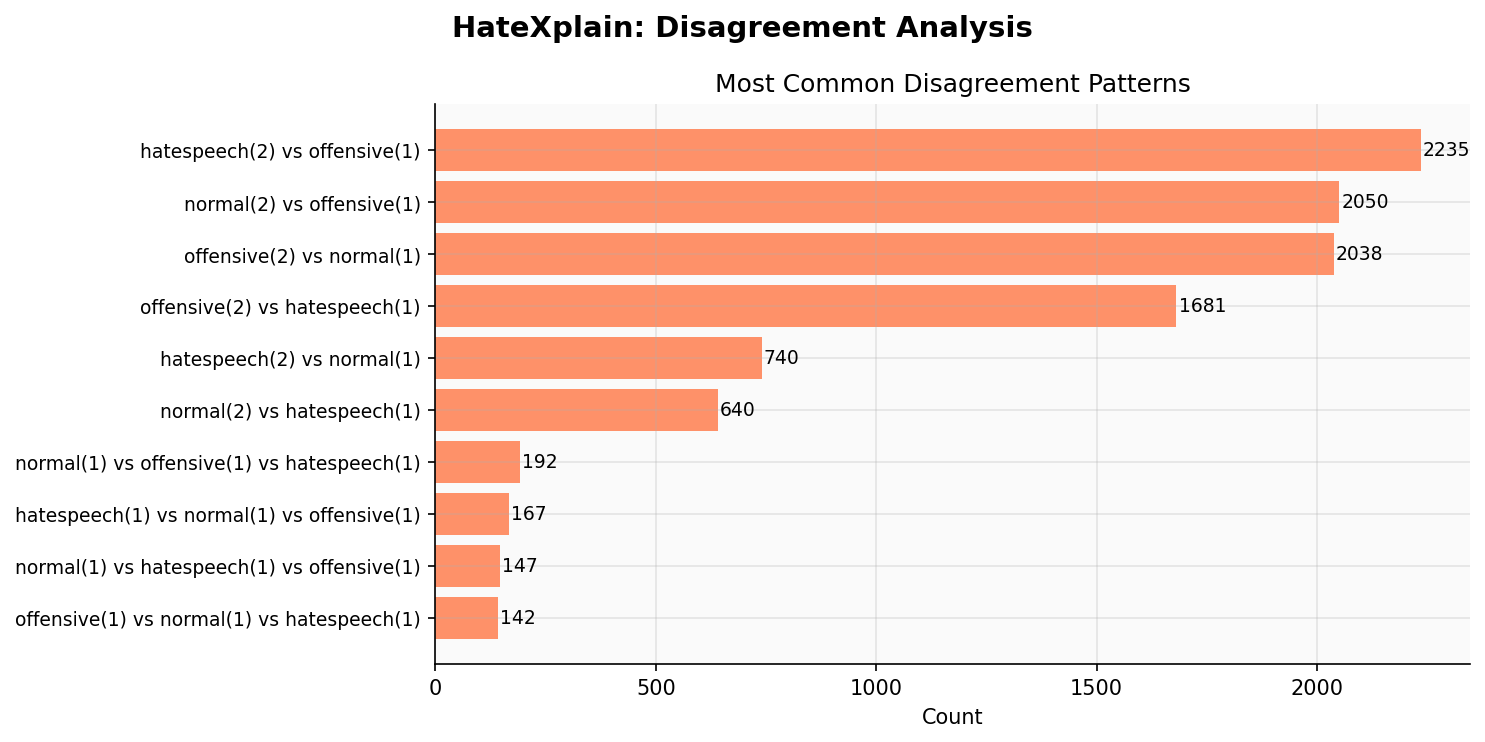


Top 5 disagreement patterns:
vote_pattern
hatespeech(2) vs offensive(1)    2235
normal(2) vs offensive(1)        2050
offensive(2) vs normal(1)        2038
offensive(2) vs hatespeech(1)    1681
hatespeech(2) vs normal(1)        740
Name: count, dtype: int64

Key insight: hatespeech(2) vs offensive(1) is the most common disagreement


In [11]:
dis_df = df[~df['all_agree']].copy()

print(f"Disagreement posts: {len(dis_df):,}")

def get_vote_pattern(votes):
    c = Counter(votes)
    sorted_votes = sorted(c.items(), key=lambda x: -x[1])
    return ' vs '.join(
        [f"{k}({v})" for k, v in sorted_votes]
    )

dis_df['vote_pattern'] = dis_df['votes'].apply(get_vote_pattern)

fig, ax = plt.subplots(figsize=(10, 5))

fig.suptitle(
    'HateXplain: Disagreement Analysis',
    fontsize=14,
    fontweight='bold'
)

patterns = dis_df['vote_pattern'].value_counts().head(10)

ax.barh(
    range(len(patterns)),
    patterns.values,
    color='coral',
    alpha=0.85
)

ax.set_yticks(range(len(patterns)))
ax.set_yticklabels(patterns.index, fontsize=9)

ax.invert_yaxis()

ax.set_title('Most Common Disagreement Patterns')
ax.set_xlabel('Count')

for i, (_, val) in enumerate(patterns.items()):
    ax.text(val + 5, i, str(val), va='center', fontsize=9)

plt.tight_layout()

plt.savefig(
    PLOTS_DIR / '07_disagreement_analysis.png',
    bbox_inches='tight'
)

plt.show()

print("\nTop 5 disagreement patterns:")
print(patterns.head())

print(
    f"\nKey insight: {patterns.index[0]} "
    f"is the most common disagreement"
)

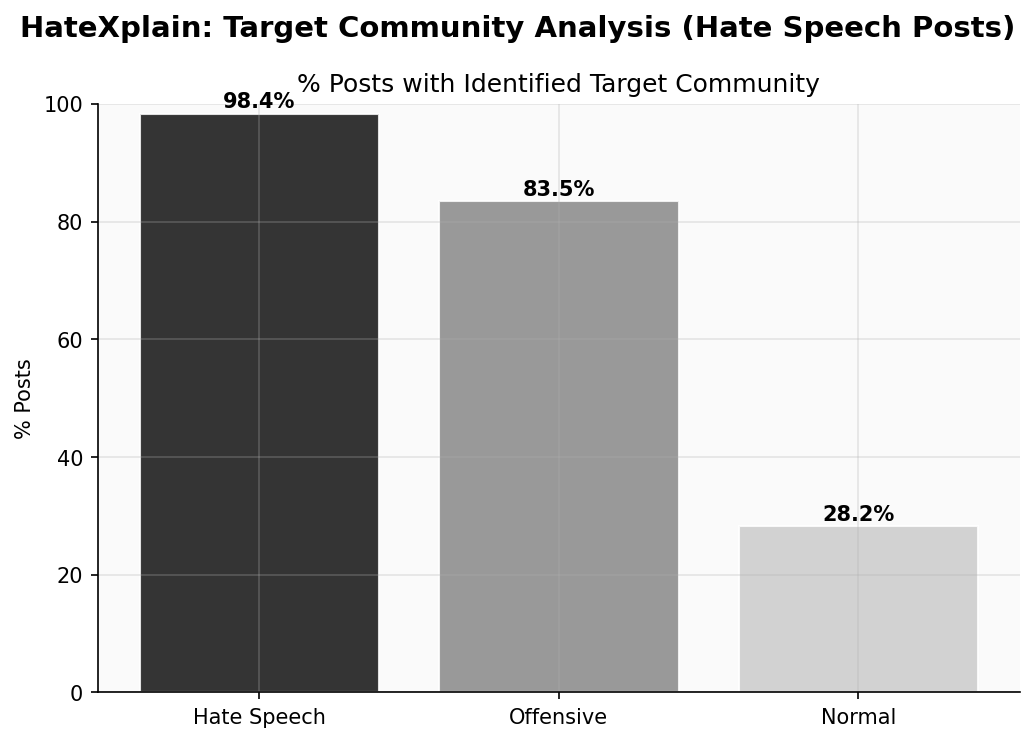


Top 10 targeted communities in hate speech:
  African               2125 posts
  Jewish                1131 posts
  Islam                 1018 posts
  Homosexual             538 posts
  Arab                   369 posts
  Hispanic               188 posts
  Women                  185 posts
  Other                  159 posts
  Refugee                148 posts
  Asian                  143 posts


In [13]:
# Targets in hate speech posts only
hate_df = df[df['label'] == 'hatespeech'].copy()

fig, ax = plt.subplots(figsize=(7, 5))
fig.suptitle('HateXplain: Target Community Analysis (Hate Speech Posts)',
             fontsize=14, fontweight='bold')

# All targets in hate posts
target_counts = Counter(hate_df['primary_target']).most_common(20)
targets, counts = zip(*target_counts)

for cls in CLS_NAMES:
    targets_cls = df[df['label']==cls]['primary_target']
    has_target  = (targets_cls != 'None').sum()
    no_target   = (targets_cls == 'None').sum()
    ax.bar(CLS_DISPLAY[cls], has_target / len(targets_cls) * 100,
           color=CLS_COLORS[cls], alpha=0.85, edgecolor='white')
ax.set_title('% Posts with Identified Target Community')
ax.set_ylabel('% Posts')
ax.set_ylim(0, 100)
for i, cls in enumerate(CLS_NAMES):
    rate = (df[df['label']==cls]['primary_target'] != 'None').mean() * 100
    ax.text(i, rate + 1, f'{rate:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(PLOTS_DIR / '08_target_communities.png', bbox_inches='tight')
plt.show()

print(f"\nTop 10 targeted communities in hate speech:")
for t, c in target_counts[:10]:
    print(f"  {t:<20} {c:>5} posts")

In [14]:
print("=" * 60)
print("HATEXPLAIN — FINAL DATA QUALITY REPORT")
print("=" * 60)

total = len(df)
report = {
    'Total posts':              total,
    'Unique posts':             df['text'].nunique(),
    'Duplicates':               total - df['text'].nunique(),
    'Missing text':             df['text'].isnull().sum(),
    'Missing labels':           df['label'].isnull().sum(),
    'Full annotator agreement': f"{df['all_agree'].sum():,} ({df['all_agree'].mean()*100:.1f}%)",
    'Posts with rationales':    f"{(df['rationale_density']>0).sum():,} ({(df['rationale_density']>0).mean()*100:.1f}%)",
    'Class balance ratio':      f"1 : {df['label'].value_counts().max()/df['label'].value_counts().min():.1f} (max/min)",
    'Fleiss Kappa':             f"{kappa:.4f}",
    'Mean word count':          f"{df['word_count'].mean():.1f}",
    'Median word count':        f"{df['word_count'].median():.1f}",
    '95th pct word count':      f"{df['word_count'].quantile(0.95):.0f}",
}

for k, v in report.items():
    print(f"  {k:<35} {v}")

print("=" * 60)

HATEXPLAIN — FINAL DATA QUALITY REPORT
  Total posts                         20148
  Unique posts                        20109
  Duplicates                          39
  Missing text                        0
  Missing labels                      0
  Full annotator agreement            9,845 (48.9%)
  Posts with rationales               11,413 (56.6%)
  Class balance ratio                 1 : 1.4 (max/min)
  Fleiss Kappa                        0.4597
  Mean word count                     23.6
  Median word count                   21.0
  95th pct word count                 49
